 # Exploratory Data Analysis (EDA)

## Project
Private Equity Acquisitions and Worker Outcomes (Industry-Level)

## Purpose
This notebook performs initial descriptive analysis of industry-level labor outcomes
and private equity exposure. The goal is to understand data coverage, trends, and
basic relationships prior to any modeling.

No causal claims are made in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
raw_dirs = [
    Path("/Users/brockjohnson/Downloads/2024.annual.by_area"),
    Path("/Users/brockjohnson/Downloads/2023.annual.by_area"),
    Path("/Users/brockjohnson/Downloads/2022.annual.by_area"),
    Path("/Users/brockjohnson/Downloads/2021.annual.by_area"),
    Path("/Users/brockjohnson/Downloads/2020.annual.by_area"),
]

In [3]:
files = []
for d in raw_dirs:
    files.extend(d.glob("*.csv"))

len(files)

15355

In [4]:
dfs = []
for f in files:
    df = pd.read_csv(f, dtype=str)
    dfs.append(df)

qcew = pd.concat(dfs, ignore_index=True)
qcew.shape

(11116483, 43)

In [5]:
qcew_us = qcew[
    (qcew["area_fips"] == "US000") &  # U.S. TOTAL
    (qcew["own_code"] == "0") &      # Total Covered
    (qcew["qtr"] == "A")             # Annual
].copy()

qcew_us.shape

(3, 43)

In [6]:
qcew_us[["agglvl_code", "agglvl_title"]].drop_duplicates().sort_values("agglvl_code")

,agglvl_code,agglvl_title
295995,10,"National, Total Covered"


In [7]:
qcew_us[["industry_code", "industry_title"]].drop_duplicates().head(30)

,industry_code,industry_title
295995,10,"10 Total, all industries"


In [8]:
qcew_us["industry_code"].value_counts().head(20)

industry_code
10    3
Name: count, dtype: int64

In [9]:
industry_dirs = [
    Path("/Users/brockjohnson/Downloads/2024.annual.by_industry"),
    Path("/Users/brockjohnson/Downloads/2023.annual.by_industry"),
    Path("/Users/brockjohnson/Downloads/2022.annual.by_industry"),
    Path("/Users/brockjohnson/Downloads/2021.annual.by_industry"),
    Path("/Users/brockjohnson/Downloads/2020.annual.by_industry"),
]

In [10]:
files = []
for d in industry_dirs:
    files.extend(d.glob("*.csv"))

len(files)

10939

In [11]:
dfs = []
for f in files:
    df = pd.read_csv(f, dtype=str)
    dfs.append(df)

qcew_ind = pd.concat(dfs, ignore_index=True)
qcew_ind.shape

(18169564, 43)

In [12]:
qcew_ind[["industry_code", "industry_title"]].drop_duplicates().head(20)

,industry_code,industry_title
0,444120,NAICS 444120 Paint and wallpaper retailers
1899,92214,NAICS 92214 Correctional institutions
4072,512191,NAICS 512191 Teleproduction and other postprod...
4848,325194,"NAICS 325194 Cyclic crude, intermediate, and g..."
5002,333248,NAICS 333248 All other industrial machinery ma...
6262,423320,"NAICS 423320 Brick, stone, and related constru..."
7948,48521,NAICS 48521 Interurban and rural bus transport...
8559,45931,NAICS 45931 Florists
11392,111,NAICS 111 Crop production
14775,81221,NAICS 81221 Funeral homes and funeral services


In [13]:
qcew_ind[["agglvl_code", "agglvl_title"]].drop_duplicates().sort_values("agglvl_code")

,agglvl_code,agglvl_title
2728168,10,"National, Total Covered"
2728169,11,"National, Total -- by ownership sector"
2678466,12,"National, by Domain -- by ownership sector"
148382,13,"National, by Supersector -- by ownership sector"
32835,14,"National, NAICS Sector -- by ownership sector"
14771,15,"National, NAICS 3-digit -- by ownership sector"
25202,16,"National, NAICS 4-digit -- by ownership sector"
4069,17,"National, NAICS 5-digit -- by ownership sector"
1898,18,"National, NAICS 6-digit -- by ownership sector"
2727984,30,"CMSA or CSA, Total Covered"


In [14]:
qcew_sector = (
    qcew_ind
    .loc[
        (qcew_ind["agglvl_code"] == "14") &  # National, NAICS Sector
        (qcew_ind["own_code"] == "1") &      # Private sector
        (qcew_ind["qtr"] == "A")             # Annual
    ]
    .copy()
)

qcew_sector.shape

(91, 43)

In [15]:
qcew_ind.loc[qcew_ind["agglvl_code"] == "14", "own_code"].value_counts()

own_code
3    100
5    100
2     92
1     91
Name: count, dtype: int64

In [16]:
qcew_sector = qcew_ind[
    (qcew_ind["agglvl_code"] == "14") &
    (qcew_ind["own_code"] == "1") &   # Private sector
    (qcew_ind["qtr"] == "A")
].copy()

qcew_sector.shape

(91, 43)

In [17]:
qcew_sector["own_code"].value_counts()

own_code
1    91
Name: count, dtype: int64

In [18]:
qcew_sector[["industry_code", "industry_title"]].drop_duplicates().sort_values("industry_code")

,industry_code,industry_title
3447851,11,"NAICS 11 Agriculture, forestry, fishing and hu..."
1558507,22,NAICS 22 Utilities
1482115,23,NAICS 23 Construction
3437384,31-33,NAICS 31-33 Manufacturing
3000118,42,NAICS 42 Wholesale trade
1685980,44-45,NAICS 44-45 Retail trade
2242382,48-49,NAICS 48-49 Transportation and warehousing
2870112,51,NAICS 51 Information
193062,52,NAICS 52 Finance and insurance
32835,53,NAICS 53 Real estate and rental and leasing


In [19]:
qcew_sector["own_code"].value_counts()

own_code
1    91
Name: count, dtype: int64

In [20]:
qcew_sector[["industry_code", "industry_title"]].drop_duplicates().sort_values("industry_code")

,industry_code,industry_title
3447851,11,"NAICS 11 Agriculture, forestry, fishing and hu..."
1558507,22,NAICS 22 Utilities
1482115,23,NAICS 23 Construction
3437384,31-33,NAICS 31-33 Manufacturing
3000118,42,NAICS 42 Wholesale trade
1685980,44-45,NAICS 44-45 Retail trade
2242382,48-49,NAICS 48-49 Transportation and warehousing
2870112,51,NAICS 51 Information
193062,52,NAICS 52 Finance and insurance
32835,53,NAICS 53 Real estate and rental and leasing


In [21]:
#Convert key columns to numeric
num_cols = [
    "annual_avg_emplvl",
    "total_annual_wages",
    "annual_avg_wkly_wage"
]

for c in num_cols:
    qcew_sector[c] = pd.to_numeric(qcew_sector[c], errors="coerce")

In [22]:
# quick check
qcew_sector[num_cols].describe()

,annual_avg_emplvl,total_annual_wages,annual_avg_wkly_wage
count,9.100000e+01,9.100000e+01,91.000000
mean,1.605074e+05,1.500901e+10,1619.868132
std,3.896441e+05,3.944938e+10,735.904375
min,0.000000e+00,0.000000e+00,0.000000
25%,3.682500e+03,2.407447e+08,1124.500000
50%,1.192100e+04,1.181490e+09,1677.000000
75%,4.909800e+04,4.493715e+09,1987.000000
max,1.675418e+06,1.904169e+11,3184.000000


In [23]:
#Create Industry x Year df
panel = (
    qcew_sector
    .sort_values(["industry_code", "year"])
    .reset_index(drop=True)
)

panel.head()

,area_fips,own_code,industry_code,agglvl_code,size_code,year,qtr,disclosure_code,area_title,own_title,...,oty_total_annual_wages_chg,oty_total_annual_wages_pct_chg,oty_taxable_annual_wages_chg,oty_taxable_annual_wages_pct_chg,oty_annual_contributions_chg,oty_annual_contributions_pct_chg,oty_annual_avg_wkly_wage_chg,oty_annual_avg_wkly_wage_pct_chg,oty_avg_annual_pay_chg,oty_avg_annual_pay_pct_chg
0,US000,1,11,14,0,2020,A,NaN,U.S. TOTAL,Federal Government,...,22254175,8.7,0,0.0,0,0.0,124,9.3,6487,9.3
1,US000,1,11,14,0,2021,A,NaN,U.S. TOTAL,Federal Government,...,15159691,5.5,0,0.0,0,0.0,67,4.6,3449,4.5
2,US000,1,11,14,0,2022,A,NaN,U.S. TOTAL,Federal Government,...,15452526,5.3,0,0.0,0,0.0,92,6.0,4813,6.1
3,US000,1,11,14,0,2023,A,NaN,U.S. TOTAL,Federal Government,...,23766842,7.7,0,0.0,0,0.0,86,5.3,4479,5.3
4,US000,1,11,14,0,2024,A,NaN,U.S. TOTAL,Federal Government,...,46956683,14.1,0,0.0,0,0.0,131,7.7,6791,7.7


In [24]:
panel_indexed = panel.copy()

panel_indexed["empl_index_2020"] = (
    panel_indexed
    .groupby("industry_code")["annual_avg_emplvl"]
    .transform(lambda x: 100 * x / x.iloc[0])
)

In [25]:
# Create a canonical title per industry_code (most common title)
industry_labels = (
    panel
    .groupby("industry_code")["industry_title"]
    .agg(lambda x: x.value_counts().index[0])
)

industry_labels

industry_code
11       NAICS 11 Agriculture, forestry, fishing and hu...
22                                      NAICS 22 Utilities
23                                   NAICS 23 Construction
31-33                            NAICS 31-33 Manufacturing
42                                NAICS 42 Wholesale trade
44-45                             NAICS 44-45 Retail trade
48-49           NAICS 48-49 Transportation and warehousing
51                                    NAICS 51 Information
52                          NAICS 52 Finance and insurance
53             NAICS 53 Real estate and rental and leasing
54       NAICS 54 Professional, scientific, and technic...
56       NAICS 56 Administrative and support and waste ...
61                           NAICS 61 Educational services
62              NAICS 62 Health care and social assistance
71            NAICS 71 Arts, entertainment, and recreation
72                NAICS 72 Accommodation and food services
81       NAICS 81 Other services (except p

In [26]:
panel_clean = panel.copy()
panel_clean["industry_title_clean"] = panel_clean["industry_code"].map(industry_labels)

In [27]:
(panel_clean.groupby("industry_code")["year"]
 .nunique()
 .sort_values())

industry_code
42       1
11       5
81       5
72       5
71       5
62       5
61       5
56       5
54       5
53       5
52       5
51       5
48-49    5
44-45    5
31-33    5
23       5
22       5
92       5
99       5
Name: year, dtype: int64

In [28]:
# How many distinct years do we have per industry?
(panel.groupby("industry_title")["year"]
 .nunique()
 .sort_values()
 .head(20))

industry_title
NAICS 42 Wholesale trade                                                             1
NAICS 54 Professional and technical services                                         2
NAICS 81 Other services, except public administration                                2
NAICS 56 Administrative and waste services                                           2
NAICS 81 Other services (except public administration)                               3
NAICS 56 Administrative and support and waste management and remediation services    3
NAICS 54 Professional, scientific, and technical services                            3
NAICS 72 Accommodation and food services                                             5
NAICS 71 Arts, entertainment, and recreation                                         5
NAICS 62 Health care and social assistance                                           5
NAICS 61 Educational services                                                        5
NAICS 11 Agriculture, forest

In [29]:
naics_sectors = [
    '11', '22', '23', '31-33', '44-45', '48-49',
    '51', '52', '53', '54', '56', '61', '62',
    '71', '72', '81'
]

In [30]:
panel_final = panel_clean[
    panel_clean["industry_code"].isin(naics_sectors)
].copy()

In [31]:
(panel_final.groupby("industry_code")["year"]
 .nunique()
 .value_counts())

year
5    16
Name: count, dtype: int64

In [32]:
# Ensure numeric types
panel_final["year"] = pd.to_numeric(panel_final["year"], errors="coerce")
panel_final["annual_avg_emplvl"] = pd.to_numeric(panel_final["annual_avg_emplvl"], errors="coerce")
panel_final["annual_avg_wkly_wage"] = pd.to_numeric(panel_final["annual_avg_wkly_wage"], errors="coerce")

# Employment (headcount)
wide = panel_final.pivot_table(
    index=["industry_code", "industry_title_clean"],
    columns="year",
    values="annual_avg_emplvl",
    aggfunc="sum"
)

# Wages (per worker)
wide_wage = panel_final.pivot_table(
    index=["industry_code", "industry_title_clean"],
    columns="year",
    values="annual_avg_wkly_wage",
    aggfunc="mean"
)

# Payroll proxy (total labor spend)
panel_final["payroll_approx"] = (
    panel_final["annual_avg_wkly_wage"] *
    panel_final["annual_avg_emplvl"] * 52
)

wide_payroll = panel_final.pivot_table(
    index=["industry_code", "industry_title_clean"],
    columns="year",
    values="payroll_approx",
    aggfunc="sum"
)

In [33]:
growth = (
    (wide[2024] / wide[2020] - 1)
    .rename("empl_growth_2020_2024")
    .reset_index()
    .sort_values("empl_growth_2020_2024", ascending=False)
)

growth

,industry_code,industry_title_clean,empl_growth_2020_2024
2,23,NAICS 23 Construction,5.750000
15,81,NAICS 81 Other services (except public adminis...,0.113535
13,71,"NAICS 71 Arts, entertainment, and recreation",0.101982
7,52,NAICS 52 Finance and insurance,0.089259
0,11,"NAICS 11 Agriculture, forestry, fishing and hu...",0.084857
12,62,NAICS 62 Health care and social assistance,0.075108
9,54,"NAICS 54 Professional, scientific, and technic...",0.056744
11,61,NAICS 61 Educational services,0.018746
5,48-49,NAICS 48-49 Transportation and warehousing,0.007328
6,51,NAICS 51 Information,0.005120


In [34]:
growth_rounded = growth.copy()
growth_rounded["empl_growth_pct"] = (
    100 * growth_rounded["empl_growth_2020_2024"]
).round(2)

growth_rounded

,industry_code,industry_title_clean,empl_growth_2020_2024,empl_growth_pct
2,23,NAICS 23 Construction,5.750000,575.00
15,81,NAICS 81 Other services (except public adminis...,0.113535,11.35
13,71,"NAICS 71 Arts, entertainment, and recreation",0.101982,10.20
7,52,NAICS 52 Finance and insurance,0.089259,8.93
0,11,"NAICS 11 Agriculture, forestry, fishing and hu...",0.084857,8.49
12,62,NAICS 62 Health care and social assistance,0.075108,7.51
9,54,"NAICS 54 Professional, scientific, and technic...",0.056744,5.67
11,61,NAICS 61 Educational services,0.018746,1.87
5,48-49,NAICS 48-49 Transportation and warehousing,0.007328,0.73
6,51,NAICS 51 Information,0.005120,0.51


In [35]:
employment_growth = growth_rounded.merge(
    wide[2020].rename("size_2020").reset_index(),
    on=["industry_code", "industry_title_clean"],
    how="left"
)

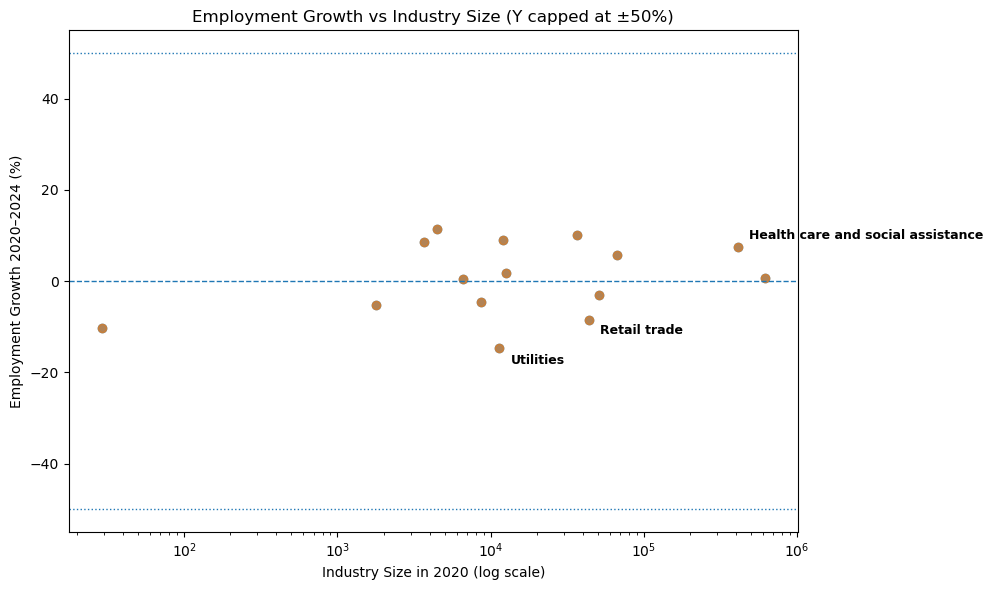

,industry_code,industry_title_clean,size_2020,empl_growth_pct
0,81,NAICS 81 Other services (except public adminis...,4492,11.35
1,71,"NAICS 71 Arts, entertainment, and recreation",36722,10.20
2,52,NAICS 52 Finance and insurance,12066,8.93
3,11,"NAICS 11 Agriculture, forestry, fishing and hu...",3665,8.49
4,62,NAICS 62 Health care and social assistance,412779,7.51
5,54,"NAICS 54 Professional, scientific, and technic...",67249,5.67
6,48-49,NAICS 48-49 Transportation and warehousing,615321,0.73
7,56,NAICS 56 Administrative and support and waste ...,1795,-5.29
8,44-45,NAICS 44-45 Retail trade,43653,-8.59
9,53,NAICS 53 Real estate and rental and leasing,29,-10.34


In [41]:

df = employment_growth.copy()

# Cap extreme growth values for visual clarity
y_cap = 50
df["empl_growth_plot"] = df["empl_growth_pct"].clip(-y_cap, y_cap)
df = df[df["industry_code"] != "23"]

plt.figure(figsize=(10, 6))
plt.scatter(df["size_2020"], df["empl_growth_plot"], alpha=0.85)

plt.xscale("log")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(y_cap, linestyle=":", linewidth=1)
plt.axhline(-y_cap, linestyle=":", linewidth=1)

plt.title(f"Employment Growth vs Industry Size (Y capped at ±{y_cap}%)")
plt.xlabel("Industry Size in 2020 (log scale)")
plt.ylabel("Employment Growth 2020–2024 (%)")

# ---- Select industries to label ----
label_df = pd.concat([
    df.nlargest(3, "empl_growth_pct"),      # top growth
    df.nsmallest(3, "empl_growth_pct"),     # bottom growth
    df.nlargest(3, "size_2020"),            # largest industries
    df.nsmallest(3, "size_2020"),           # smallest industries
]).drop_duplicates()

# Annotate plot using industry_code
plt.scatter(df["size_2020"], df["empl_growth_plot"], alpha=0.6)

key_inds = [
    "Health care and social assistance",
    "Retail trade",
    "Utilities"
]

offsets = {
    "Health care and social assistance": (8, 6),
    "Retail trade": (8, -10),
    "Utilities": (8, -12),
}

for _, r in df.iterrows():
    label = r["industry_title_clean"].split(" ", 2)[2]
    if label in offsets:
        dx, dy = offsets[label]
        plt.annotate(
            label,
            (r["size_2020"], r["empl_growth_plot"]),
            textcoords="offset points",
            xytext=(dx, dy),
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

# ---- Create Key Table Below Plot ----
key = (
    label_df[["industry_code", "industry_title_clean", "size_2020", "empl_growth_pct"]]
    .sort_values("empl_growth_pct", ascending=False)
    .reset_index(drop=True)
)

key["size_2020"] = key["size_2020"].round(0).astype(int)
key["empl_growth_pct"] = key["empl_growth_pct"].round(2)

key

Interpretation: Employment Growth and Industry Scale (2020–2024)

This figure plots employment growth against industry size in 2020 (log scale). The y-axis is capped at ±50% to prevent small sectors with extreme percentage changes from distorting the visualization.

Across most industries, employment growth is relatively modest and clustered within a narrow range. Larger industries tend to exhibit smaller percentage changes, while the most extreme growth rates occur in smaller sectors.

This pattern reflects base effects: large percentage changes in small industries often result from low starting employment levels rather than broad structural changes in the labor market.

<Figure size 1000x600 with 0 Axes>

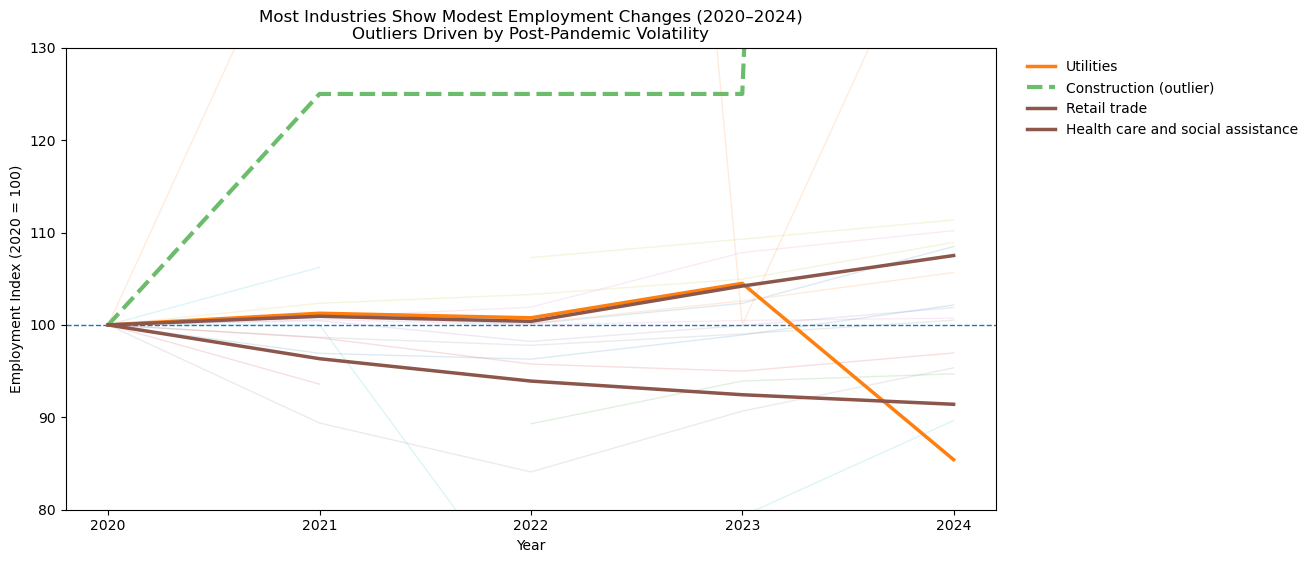

In [54]:
plt.figure(figsize=(10, 6))

highlight_inds = [
    "NAICS 62 Health care and social assistance",
    "NAICS 44-45 Retail trade",
    "NAICS 22 Utilities"
]

special_ind = "NAICS 23 Construction"  # the volatile one

plt.figure(figsize=(12, 6))

for ind, d in panel_indexed.groupby("industry_title"):
    
    if "23 Construction" in ind:
        plt.plot(
            d["year"], d["empl_index_2020"],
            linewidth=3,
            linestyle="--",
            label="Construction (outlier)",
            zorder=1,
            alpha=0.7
        )
    
    elif ind in highlight_inds:
        plt.plot(
            d["year"], d["empl_index_2020"],
            linewidth=2.5,
            label=ind.split(" ", 2)[2],
            zorder=3
        )
    
    else:
        plt.plot(
            d["year"], d["empl_index_2020"],
            alpha=0.15,
            linewidth=1,
            zorder=1
        )

plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Most Industries Show Modest Employment Changes (2020–2024)\nOutliers Driven by Post-Pandemic Volatility")
#plt.text(2020.1, 125, "Most industries cluster tightly around baseline", fontsize=9)
plt.xlabel("Year")
plt.ylabel("Employment Index (2020 = 100)")
plt.ylim(80, 130)
plt.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.show()

In [55]:
complete_inds = (
    panel_clean
    .groupby("industry_code")["year"]
    .nunique()
    .loc[lambda x: x == 5]
    .index
)
complete_inds

Index(['11', '22', '23', '31-33', '44-45', '48-49', '51', '52', '53', '54',
       '56', '61', '62', '71', '72', '81', '92', '99'],
      dtype='object', name='industry_code')

## Core Data Construction (Run Before Analysis)

In [56]:
wide.columns, wide.columns.dtype

(Index([2020, 2021, 2022, 2023, 2024], dtype='int64', name='year'),
 dtype('int64'))

In [57]:
wide = panel_final.pivot_table(
    index=["industry_code", "industry_title_clean"],
    columns="year",
    values="annual_avg_emplvl",
    aggfunc="sum"
)

wide

,year,2020,2021,2022,2023,2024
industry_code,industry_title_clean,,,,,
11,"NAICS 11 Agriculture, forestry, fishing and hunting",3665,3696,3669,3751,3976
22,NAICS 22 Utilities,11408,11552,11496,11921,9744
23,NAICS 23 Construction,4,5,5,5,27
31-33,NAICS 31-33 Manufacturing,50949,50240,48792,48401,49404
44-45,NAICS 44-45 Retail trade,43653,42057,41000,40355,39904
48-49,NAICS 48-49 Transportation and warehousing,615321,618972,615190,618284,619830
51,NAICS 51 Information,6640,6551,6493,6575,6674
52,NAICS 52 Finance and insurance,12066,12348,12463,12664,13143
53,NAICS 53 Real estate and rental and leasing,29,29,20,23,26


### Observation
Construction shows extreme post-2020 growth due to a depressed 2020 base.
This is treated as a base-year artifact and excluded from visualizations,
but retained in the underlying table.

In [58]:
# Removing outlier industry code 23
growth_plot = growth_rounded[
    growth_rounded["industry_code"] != "23"
]

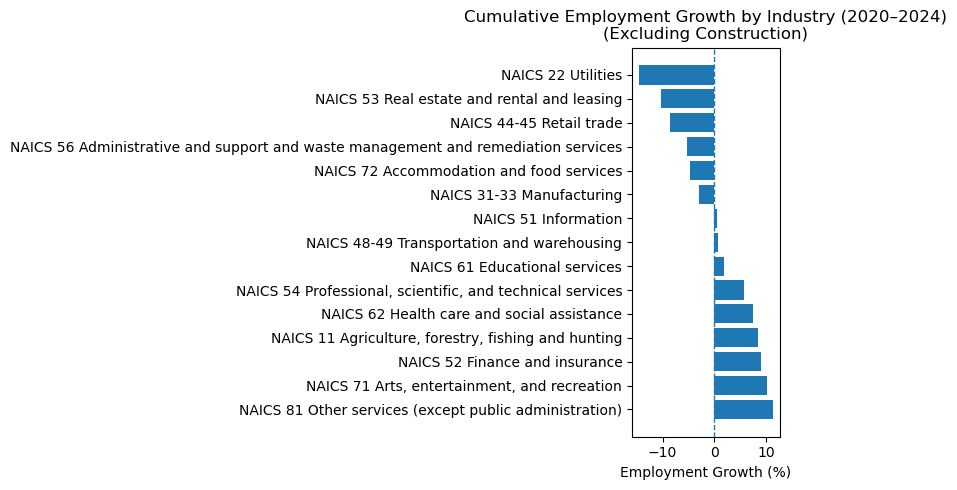

In [59]:
plt.figure(figsize=(8, 5))
plt.barh(
    growth_plot["industry_title_clean"],
    growth_plot["empl_growth_pct"]
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Cumulative Employment Growth by Industry (2020–2024)\n(Excluding Construction)")
plt.xlabel("Employment Growth (%)")
plt.tight_layout()
plt.show()

## Employment vs Wage Dynamics

After examining employment growth by industry, the next step is to compare
employment changes with wage changes. Divergence between these measures
(e.g., wages rising while employment stagnates or declines) can signal
labor market tightness, productivity changes, or restructuring pressures.

In [60]:
# Ensure wage measure is numeric
panel_final["annual_avg_wkly_wage"] = pd.to_numeric(
    panel_final["annual_avg_wkly_wage"], errors="coerce"
)

# Pivot wages to wide format (industry × year)
wide_wage = panel_final.pivot_table(
    index=["industry_code", "industry_title_clean"],
    columns="year",
    values="annual_avg_wkly_wage",
    aggfunc="mean"  # wages should be averaged, not summed
)

# Compute cumulative wage growth from 2020 to 2024
wage_growth = (
    (wide_wage[2024] / wide_wage[2020] - 1)
    .rename("wage_growth_2020_2024")
    .reset_index()
)

In [61]:
# Merge employment and wage growth into a single table
growth_combined = growth.merge(
    wage_growth,
    on=["industry_code", "industry_title_clean"],
    how="inner"
)

# Convert to percentages and round for readability
growth_combined["empl_growth_pct"] = (
    100 * growth_combined["empl_growth_2020_2024"]
).round(2)

growth_combined["wage_growth_pct"] = (
    100 * growth_combined["wage_growth_2020_2024"]
).round(2)

growth_combined[
    ["industry_title_clean", "empl_growth_pct", "wage_growth_pct"]
].sort_values("wage_growth_pct", ascending=False)

,industry_title_clean,empl_growth_pct,wage_growth_pct
11,NAICS 72 Accommodation and food services,-4.65,40.96
4,"NAICS 11 Agriculture, forestry, fishing and hu...",8.49,25.77
12,NAICS 56 Administrative and support and waste ...,-5.29,24.33
5,NAICS 62 Health care and social assistance,7.51,22.65
3,NAICS 52 Finance and insurance,8.93,20.60
1,NAICS 81 Other services (except public adminis...,11.35,19.64
14,NAICS 53 Real estate and rental and leasing,-10.34,18.29
2,"NAICS 71 Arts, entertainment, and recreation",10.20,17.91
9,NAICS 51 Information,0.51,17.63
10,NAICS 31-33 Manufacturing,-3.03,16.99


### Initial observations

Comparing employment and wage growth reveals several industries where
wages increased despite flat or declining employment. These patterns
may reflect labor shortages, productivity changes, or cost pressures
that differ by industry.

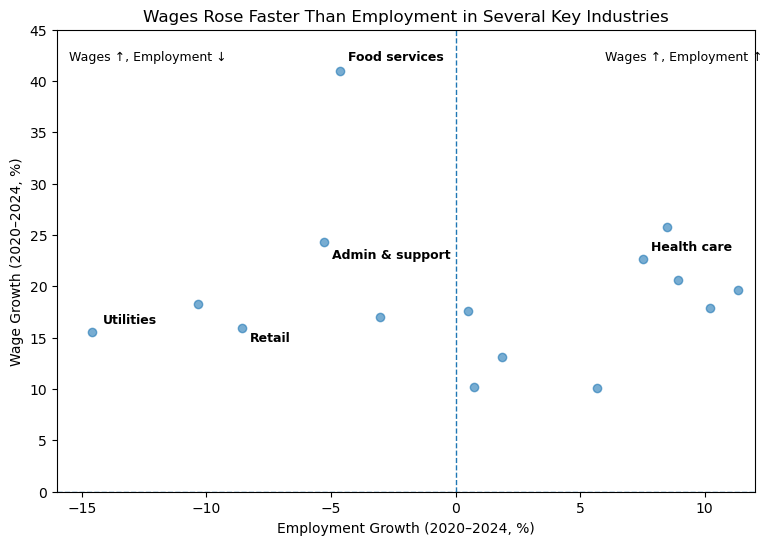

In [67]:
plt.figure(figsize=(9, 6))

scatter_data = growth_combined[growth_combined["industry_code"] != "23"].copy()

plt.scatter(
    scatter_data["empl_growth_pct"],
    scatter_data["wage_growth_pct"],
    alpha=0.6
)

key_inds = [
    "Accommodation and food services",
    "Administrative and support and waste management and remediation services",
    "Health care and social assistance",
    "Retail trade",
    "Utilities"
]

label_map = {
    "Accommodation and food services": "Food services",
    "Administrative and support and waste management and remediation services": "Admin & support",
    "Health care and social assistance": "Health care",
    "Retail trade": "Retail",
    "Utilities": "Utilities"
}

offsets = {
    "Food services": (6, 8),
    "Admin & support": (6, -12),
    "Health care": (6, 6),
    "Retail": (6, -10),
    "Utilities": (-20, -2),
}

for _, row in scatter_data.iterrows():
    full_label = row["industry_title_clean"].split(" ", 2)[2]
    if full_label in key_inds:
        label = label_map.get(full_label, full_label)

        # Custom tweak for Utilities
        if label == "Utilities":
            dx, dy = (8, 6)   # move up and right
        else:
            dx, dy = offsets[label]

        plt.annotate(
            label,
            (row["empl_growth_pct"], row["wage_growth_pct"]),
            textcoords="offset points",
            xytext=(dx, dy),
            fontsize=9,
            fontweight="bold"
        )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

# Quadrant labels (moved slightly higher for clarity)
plt.text(6, 42, "Wages ↑, Employment ↑", fontsize=9)
plt.text(-15.5, 42, "Wages ↑, Employment ↓", fontsize=9)

plt.xlabel("Employment Growth (2020–2024, %)")
plt.ylabel("Wage Growth (2020–2024, %)")
plt.title("Wages Rose Faster Than Employment in Several Key Industries")

plt.xlim(-16, 12)
plt.ylim(0, 45)  # important to create space for labels

plt.show()

Industry-specific shock effects

Accommodation and food services exhibits unusually large wage growth between 2020 and 2024. This reflects a low wage base in 2020 followed by strong post-pandemic labor demand and rapid wage adjustment. As a result, the observed growth should be interpreted as a recovery from a temporary shock rather than sustained long-run expansion.

In [72]:
# Compute the median wage growth across all industries
median_wage_growth = growth_combined["wage_growth_pct"].median()

median_wage_growth

np.float64(17.77)

In [73]:
# Extract wage growth for NAICS 72 (Accommodation and food services)
naics_72_wage = growth_combined.loc[
    growth_combined["industry_code"] == "72",
    "wage_growth_pct"
].iloc[0]

naics_72_wage

np.float64(40.96)

In [75]:
# Compute how much higher NAICS 72 wage growth is relative to the median
wage_gap = naics_72_wage - median_wage_growth

wage_gap

np.float64(23.19)

Wage growth relative to the median

Accommodation and food services (NAICS 72) experienced wage growth of approximately 41% between 2020 and 2024. In comparison, the median industry wage growth over the same period was approximately 18%. This implies that wage growth in this sector exceeded the median by roughly 23 percentage points.

This outsized increase reflects a combination of a low wage base during the COVID-19 shock and strong post-pandemic labor demand. As a result, this growth should be interpreted as a recovery from a temporary shock rather than sustained long-run expansion.


In [76]:
# Create a working copy of the combined growth table
cost_pressure = growth_combined.copy()

# Labor cost pressure = wage growth minus employment growth (percentage points)
# Positive values indicate wages rising faster than employment
cost_pressure["labor_cost_pressure_pp"] = (
    cost_pressure["wage_growth_pct"] -
    cost_pressure["empl_growth_pct"]
).round(2)

# Sort industries from highest to lowest cost pressure
cost_pressure = cost_pressure.sort_values(
    "labor_cost_pressure_pp",
    ascending=False
)

# Display the key results
cost_pressure[
    [
        "industry_title_clean",
        "empl_growth_pct",
        "wage_growth_pct",
        "labor_cost_pressure_pp"
    ]
]

,industry_title_clean,empl_growth_pct,wage_growth_pct,labor_cost_pressure_pp
11,NAICS 72 Accommodation and food services,-4.65,40.96,45.61
15,NAICS 22 Utilities,-14.59,15.59,30.18
12,NAICS 56 Administrative and support and waste ...,-5.29,24.33,29.62
14,NAICS 53 Real estate and rental and leasing,-10.34,18.29,28.63
13,NAICS 44-45 Retail trade,-8.59,15.98,24.57
10,NAICS 31-33 Manufacturing,-3.03,16.99,20.02
4,"NAICS 11 Agriculture, forestry, fishing and hu...",8.49,25.77,17.28
9,NAICS 51 Information,0.51,17.63,17.12
5,NAICS 62 Health care and social assistance,7.51,22.65,15.14
3,NAICS 52 Finance and insurance,8.93,20.60,11.67


### Labor cost pressure

Labor cost pressure is defined as the difference between wage growth and employment growth, measured in percentage points. Positive values indicate industries where wages are rising faster than workforce expansion, increasing per-worker labor costs.

### Industries with highest labor cost pressure

Accommodation and food services, utilities, and administrative and support services exhibit the highest labor cost pressure. In these industries, wage growth substantially exceeds employment growth.

While accommodation and food services reflects post-pandemic recovery dynamics, utilities and administrative services display patterns more consistent with structural labor constraints and rising per-worker costs.

These conditions may create environments where firms face margin pressure, potentially increasing incentives for cost restructuring, consolidation, or operational efficiency improvements.

### Payroll growth as context

To distinguish changes in per-worker wages from overall labor spending, total annual payroll is approximated as average weekly wage multiplied by average employment and 52 weeks.

Payroll growth captures changes in total labor compensation and provides additional context for interpreting labor cost pressure.

In [83]:
# Compute payroll growth between 2020 and 2024
payroll_growth = (
    (wide_payroll[2024] / wide_payroll[2020] - 1)
    .rename("payroll_growth_2020_2024")
    .reset_index()
)

# Convert to percentage terms
payroll_growth["payroll_growth_pct"] = (
    100 * payroll_growth["payroll_growth_2020_2024"]
).round(2)

# Merge payroll growth into the existing growth table
growth_plus = growth_combined.merge(
    payroll_growth[
        ["industry_code", "industry_title_clean", "payroll_growth_pct"]
    ],
    on=["industry_code", "industry_title_clean"],
    how="left"
)

In [86]:
growth_plus["labor_cost_pressure_pp"] = (
    growth_plus["wage_growth_pct"] - growth_plus["empl_growth_pct"]
).round(2)

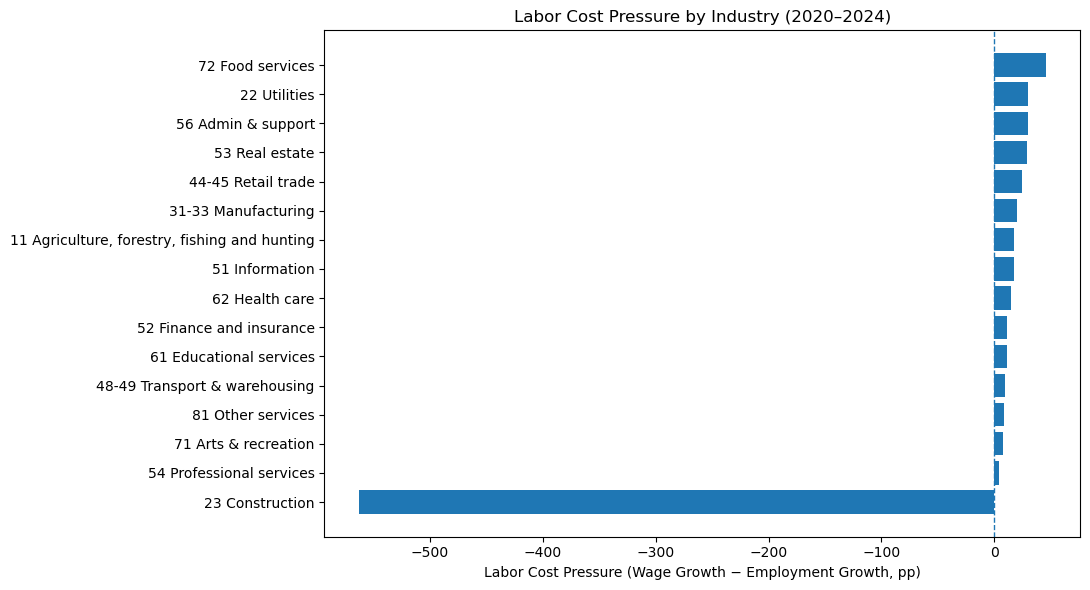

In [94]:

# Sort by labor cost pressure
plot_df = growth_plus.sort_values("labor_cost_pressure_pp", ascending=False).copy()

# Create shortened, presentation-friendly labels
plot_df["industry_short"] = (
    plot_df["industry_title_clean"]
    .str.replace("NAICS ", "")
    .str.replace("Administrative and support and waste management and remediation services", "Admin & support")
    .str.replace("Accommodation and food services", "Food services")
    .str.replace("Health care and social assistance", "Health care")
    .str.replace("Real estate and rental and leasing", "Real estate")
    .str.replace("Professional, scientific, and technical services", "Professional services")
    .str.replace("Transportation and warehousing", "Transport & warehousing")
    .str.replace("Arts, entertainment, and recreation", "Arts & recreation")
    .str.replace("Other services \\(except public administration\\)", "Other services", regex=True)
)

# Create figure
plt.figure(figsize=(11, 6))

# Plot bars
plt.barh(
    plot_df["industry_short"],
    plot_df["labor_cost_pressure_pp"]
)

# Reference line at zero
plt.axvline(0, linestyle="--", linewidth=1)

# Titles and labels
plt.title("Labor Cost Pressure by Industry (2020–2024)")
plt.xlabel("Labor Cost Pressure (Wage Growth − Employment Growth, pp)")
plt.ylabel("")

# Highest values at top
plt.gca().invert_yaxis()

# Layout + save
plt.tight_layout()
plt.savefig("../figures/labor_cost_pressure.png", dpi=300, bbox_inches="tight")

plt.show()

Interpretation: Labor Cost Pressure (2020–2024)

This figure shows labor cost pressure by industry. Positive values indicate industries where wage growth outpaced employment growth, suggesting rising labor cost intensity.

Several industries exhibit substantial positive labor cost pressure, reflecting wage gains that were not matched by workforce expansion. In some cases, employment declined while wages increased, indicating that total labor spending is increasingly driven by higher compensation per worker rather than headcount growth.

These results do not imply private equity involvement directly. Instead, they identify industry environments where sustained cost pressure may influence firm behavior, including restructuring, consolidation, or efficiency improvements.


In [99]:
growth_plus[
    [
        "industry_title_clean",
        "empl_growth_pct",
        "wage_growth_pct",
        "payroll_growth_pct",
        "labor_cost_pressure_pp",
    ]
].sort_values("labor_cost_pressure_pp", ascending=False)

,industry_title_clean,empl_growth_pct,wage_growth_pct,payroll_growth_pct,labor_cost_pressure_pp
11,NAICS 72 Accommodation and food services,-4.65,40.96,34.41,45.61
15,NAICS 22 Utilities,-14.59,15.59,-1.27,30.18
12,NAICS 56 Administrative and support and waste ...,-5.29,24.33,17.75,29.62
14,NAICS 53 Real estate and rental and leasing,-10.34,18.29,6.05,28.63
13,NAICS 44-45 Retail trade,-8.59,15.98,6.02,24.57
10,NAICS 31-33 Manufacturing,-3.03,16.99,13.45,20.02
4,"NAICS 11 Agriculture, forestry, fishing and hu...",8.49,25.77,36.44,17.28
9,NAICS 51 Information,0.51,17.63,18.23,17.12
5,NAICS 62 Health care and social assistance,7.51,22.65,31.87,15.14
3,NAICS 52 Finance and insurance,8.93,20.60,31.36,11.67
